# 1. Preprocessing
Load the CIFAR-10 dataset, visualize samples, and normalize the images.

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
os.environ["TF_use_legacy_keras"] = "1"

# Load CIFAR-10:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape)  # (50000, 32, 32, 3)
print(x_test.shape)   # (10000, 32, 32, 3)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [ ]:
print(tf.__version__)


2.19.0


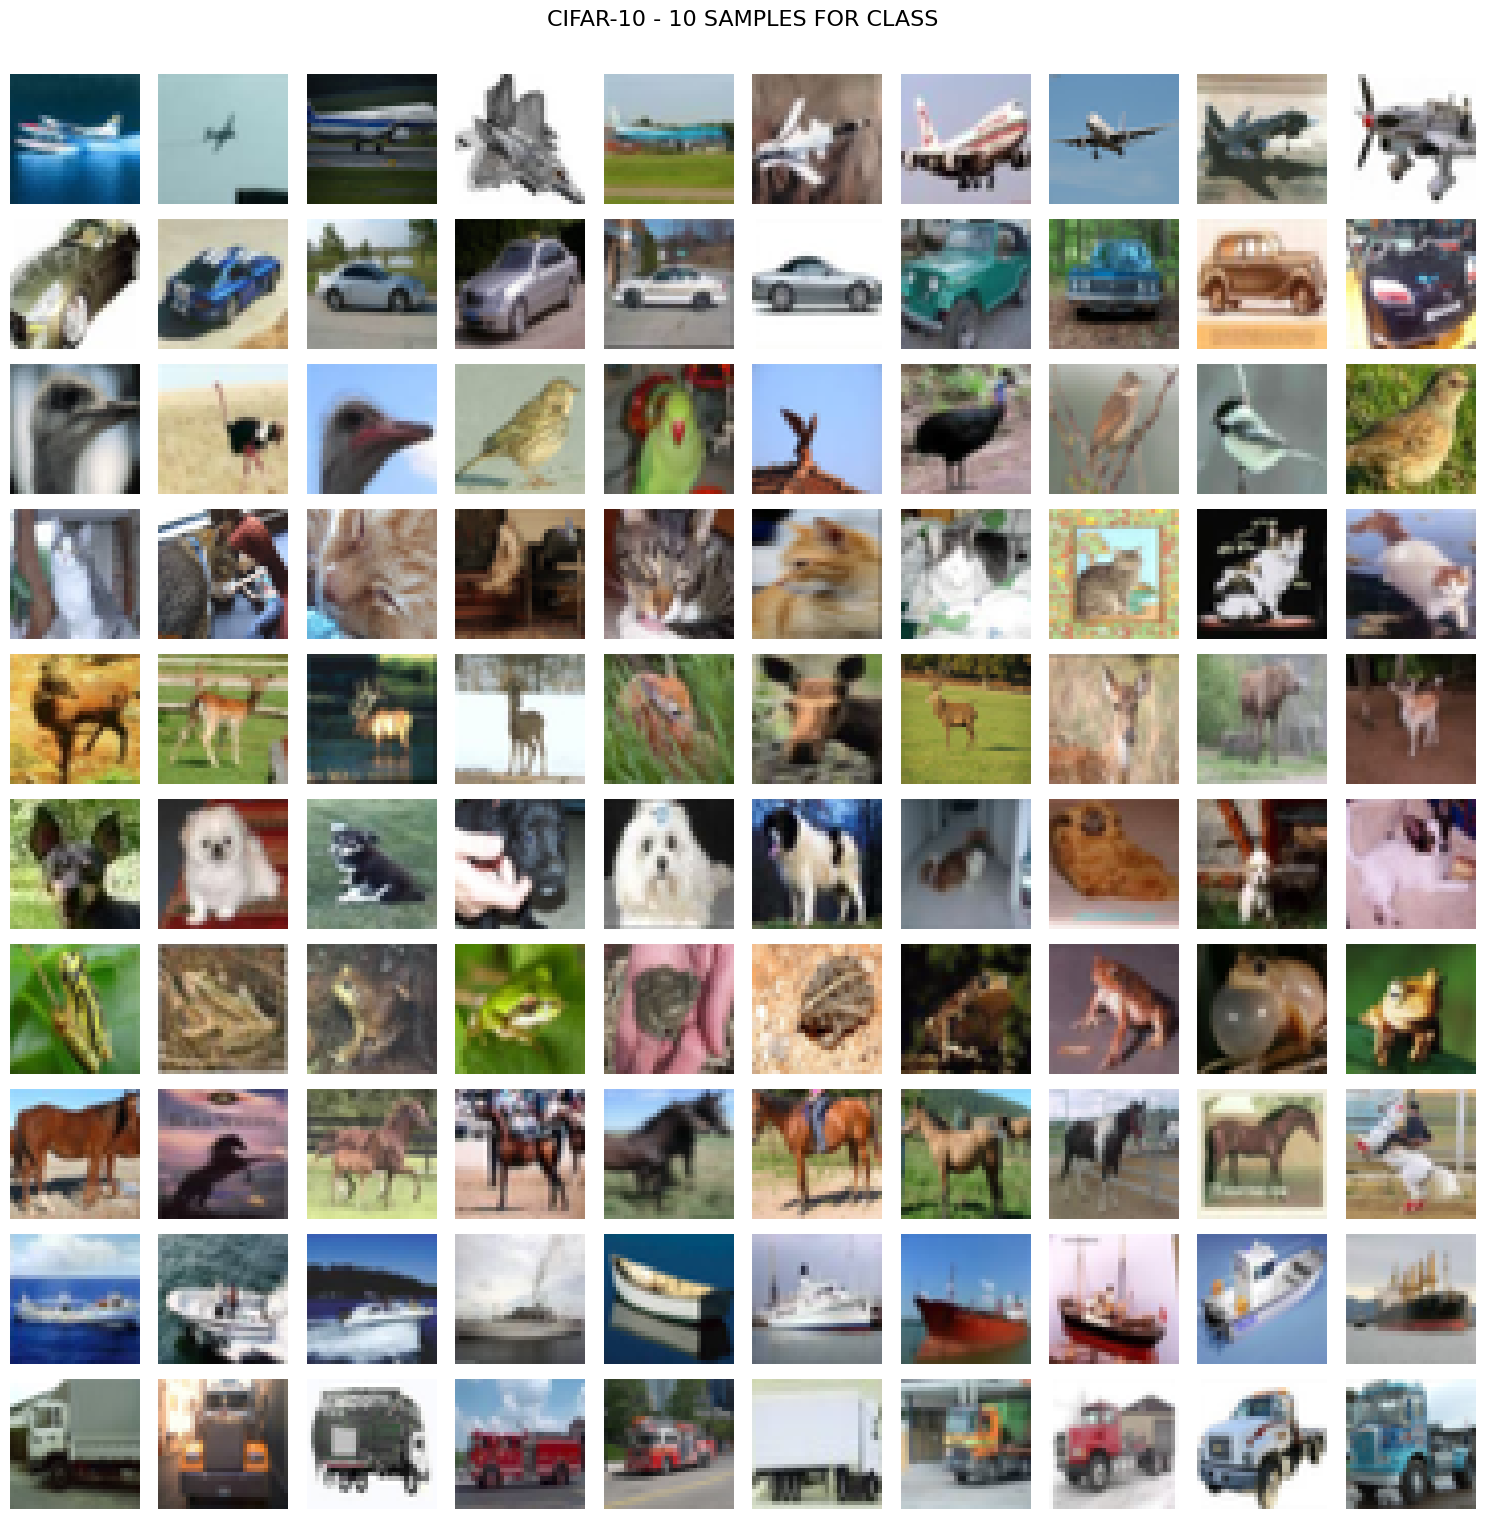

pixel min= 0.0 pixel max= 1.0


In [ ]:
# ── Class names for CIFAR-10 ─────────────────────────────────────────────────
class_names = ["airplane", "automoblie", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

# ── Visualize: 10x10 grid ────────────────────────────────────────────────────
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
fig.suptitle("CIFAR-10 - 10 SAMPLES FOR CLASS", fontsize=16, y=1.01)

for class_idx in range(10):
    # Find all indices belonging to this class
    indices = np.where(y_train.flatten() == class_idx)[0]
    # Randomly pick 10 without repetition
    samples = np.random.choice(indices, 10, replace=False)
    for col, sample_idx in enumerate(samples):
        ax = axes[class_idx, col]
        ax.imshow(x_train[sample_idx])
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(class_names[class_idx], fontsize=9,
                          rotation=0, labelpad=50, va="center")

plt.tight_layout()
plt.show()

# ── Normalize pixel values from [0,255] to [0,1] ─────────────────────────────
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm  = x_test.astype("float32")  / 255.0
print("pixel min=", x_train_norm.min(), "pixel max=", x_train_norm.max())


# 2. Model Architecture
A deep CNN with 3 convolutional blocks following the VGG-style architecture.
Each block extracts increasingly complex visual features from the images.

In [ ]:
# Clear any previous model from memory to avoid conflicts
from keras.backend import clear_session
clear_session()


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                      Dense, Dropout, BatchNormalization)
from tensorflow.keras.optimizers import Adam

# ── Model Architecture ───────────────────────────────────────────────────────


model9 = Sequential([

    # ── Block 1: Detect basic features (edges, colors) ───────────────────────

    Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(32, 32, 3)),

    BatchNormalization(),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # ── Block 2: Detect intermediate features (shapes, textures) ─────────────
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # ── Block 3: Detect complex features (object parts, high-level patterns) ──
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # ── Classifier Head ──────────────────────────────────────────────────────
    Flatten(),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

model9.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

# 3. Training
Split data, apply Data Augmentation, define callbacks and train the model.

In [ ]:
# ── Train / Validation Split ─────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

x_train_split, x_val, y_train_split, y_val = train_test_split(
    x_train_norm, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print(f"Training samples:   {x_train_split.shape[0]}")
print(f"Validation samples: {x_val.shape[0]}")


Training samples:   45000
Validation samples: 5000


In [ ]:
# ── Data Augmentation ────────────────────────────────────────────────────────
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(x_train_split)

# ── Callbacks ────────────────────────────────────────────────────────────────
# EarlyStopping: stops training if val_loss does not improve for 15 epochs.
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=7, min_lr=1e-6, verbose=1
    )
]

# ── Compile the model ────────────────────────────────────────────────────────
model9.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ── Train the model ──────────────────────────────────────────────────────────
history = model9.fit(
    datagen.flow(x_train_split, y_train_split, batch_size=64),
    epochs=50,
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 47ms/step - accuracy: 0.3648 - loss: 1.9357 - val_accuracy: 0.5184 - val_loss: 1.3246 - learning_rate: 5.0000e-04
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.5016 - loss: 1.3924 - val_accuracy: 0.4940 - val_loss: 1.5419 - learning_rate: 5.0000e-04
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.5775 - loss: 1.1796 - val_accuracy: 0.6368 - val_loss: 1.0396 - learning_rate: 5.0000e-04
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.6248 - loss: 1.0578 - val_accuracy: 0.6530 - val_loss: 1.0060 - learning_rate: 5.0000e-04
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.6608 - loss: 0.9717 - val_accuracy: 0.6448 - val_loss: 1.0387 - learning_rate: 5.0000e-04
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.6843 - loss: 0.9011 - val_accuracy: 0.6962 - val_loss: 0.8985 - learning_rate: 5.0000e-04
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/ste

# 4. Complete Evaluation
1. Loss & Accuracy Curves
2. Final Metrics Summary
3. Confusion Matrix
4. Misclassified Images
5. Classification Report

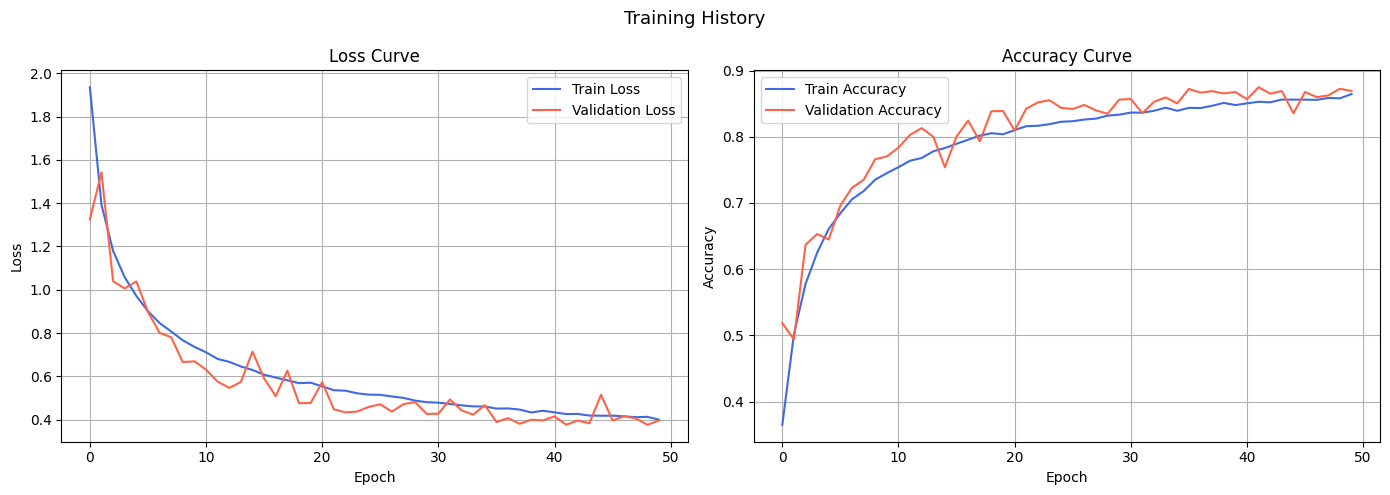

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ── 4.1 Loss & Accuracy Curves ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History", fontsize=13)

axes[0].plot(history.history["loss"],     label="Train Loss",      color="royalblue")
axes[0].plot(history.history["val_loss"], label="Validation Loss", color="tomato")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history["accuracy"],     label="Train Accuracy",      color="royalblue")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy", color="tomato")
axes[1].set_title("Accuracy Curve")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# ── 4.2 Final Metrics Summary ────────────────────────────────────────────────
train_loss     = history.history["loss"]
train_accuracy = history.history["accuracy"]

val_loss_final, val_acc_final = model9.evaluate(x_val, y_val, verbose=0)
test_loss, test_accuracy = model9.evaluate(x_test_norm, y_test, verbose=0)

print("=" * 55)
print("           COMPLETE EVALUATION SUMMARY")
print("=" * 55)
print(f"  Final Training Loss:       {train_loss[-1]:.4f}")
print(f"  Final Training Accuracy:   {train_accuracy[-1]*100:.2f}%")
print(f"  Final Validation Loss:     {val_loss_final:.4f}")
print(f"  Final Validation Accuracy: {val_acc_final*100:.2f}%")
print("-" * 55)
print(f"  Test Loss:                 {test_loss:.4f}")
print(f"  Test Accuracy:             {test_accuracy*100:.2f}%")
print("=" * 55)

# Overfitting check
gap = train_accuracy[-1] - val_acc_final
if gap < 0.05:
    print("  Overfitting: NONE — Train and Val accuracy are close")
elif gap < 0.10:
    print("  Overfitting: MILD — small gap between Train and Val")
else:
    print("  Overfitting: WARNING — large gap between Train and Val")


           COMPLETE EVALUATION SUMMARY
  Final Training Loss:       0.3999
  Final Training Accuracy:   86.44%
  Final Validation Loss:     0.3762
  Final Validation Accuracy: 87.24%
-------------------------------------------------------
  Test Loss:                 0.4188
  Test Accuracy:             86.44%
  Overfitting: NONE — Train and Val accuracy are close


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


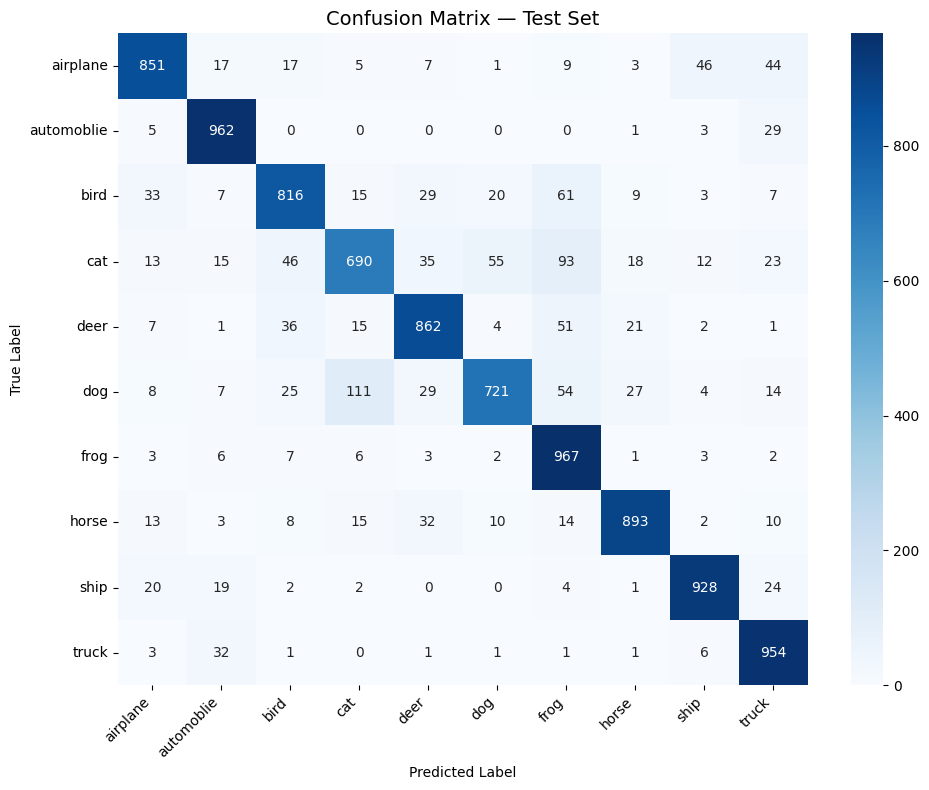

In [ ]:
# ── 4.3 Confusion Matrix ─────────────────────────────────────────────────────
y_test_pred_probs = model9.predict(x_test_norm)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)
y_test_true = y_test.flatten()

cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Test Set", fontsize=14)
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Total misclassified: 1356 out of 10000
Correctly classified: 8644


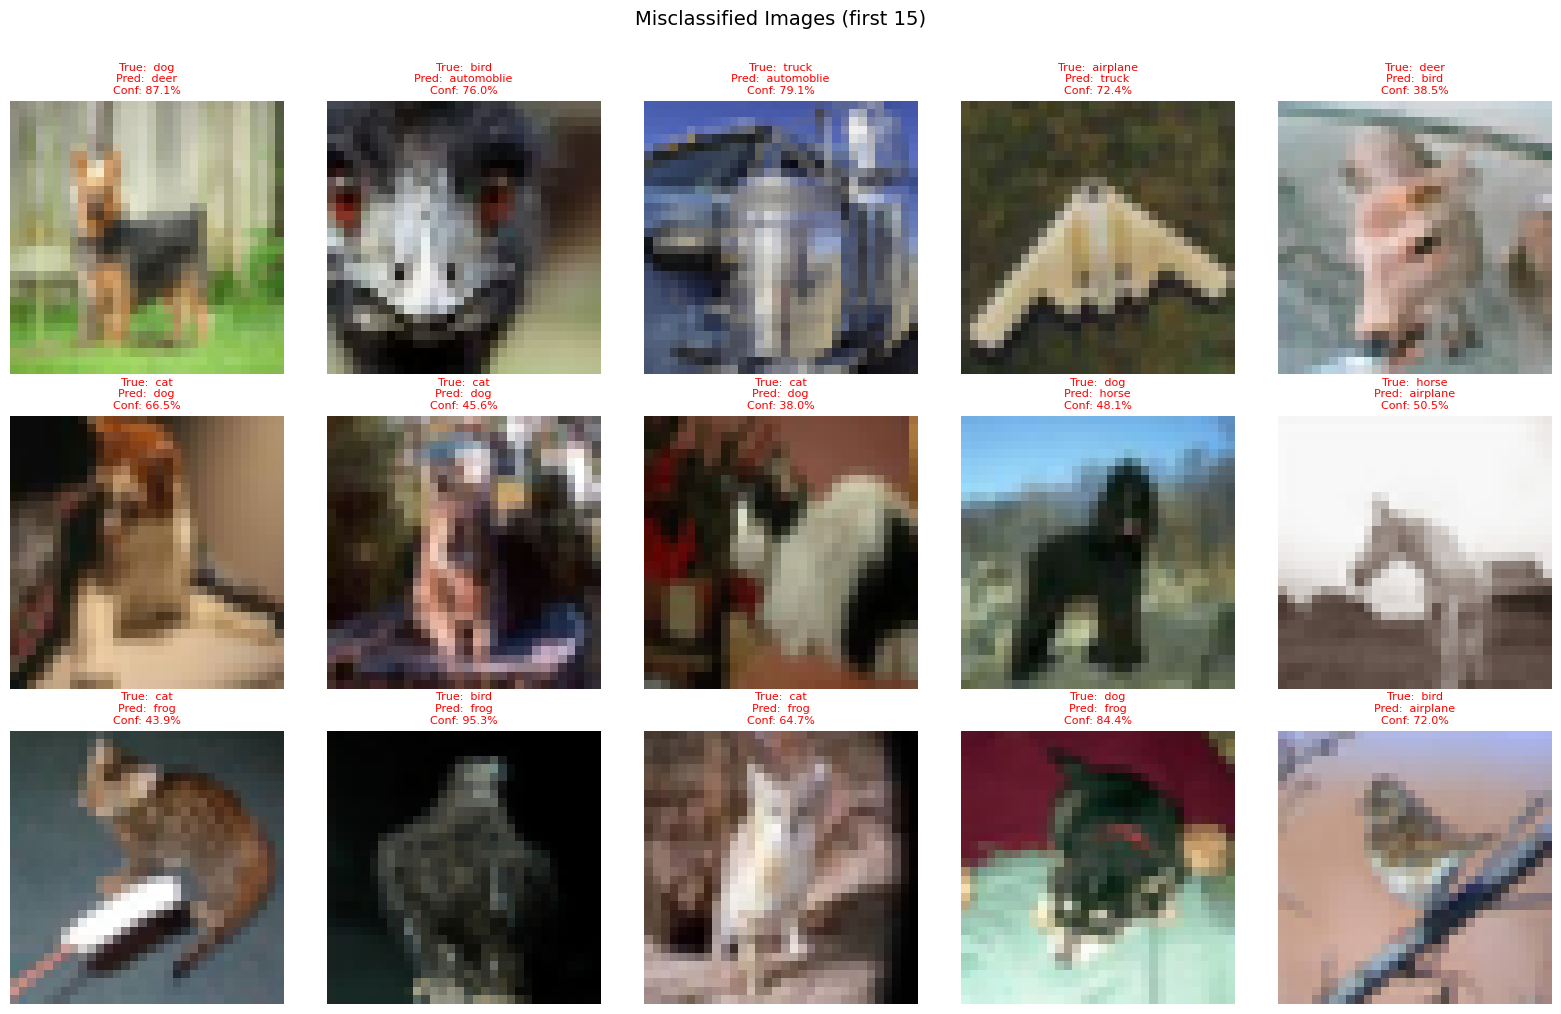

In [ ]:
# ── 4.4 Misclassified Images ─────────────────────────────────────────────────
wrong_idx = np.where(y_test_pred != y_test_true)[0]
print(f"Total misclassified: {len(wrong_idx)} out of {len(y_test_true)}")
print(f"Correctly classified: {len(y_test_true) - len(wrong_idx)}")

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
fig.suptitle("Misclassified Images (first 15)", fontsize=14, y=1.01)

for i, idx in enumerate(wrong_idx[:15]):
    ax = axes[i // 5, i % 5]
    ax.imshow(x_test[idx])  # show original 32x32 image
    true_label = class_names[y_test_true[idx]]
    pred_label = class_names[y_test_pred[idx]]
    confidence = y_test_pred_probs[idx][y_test_pred[idx]] * 100
    ax.set_title(
        f"True:  {true_label}\nPred:  {pred_label}\nConf: {confidence:.1f}%",
        color="red", fontsize=8
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# ── 4.5 Classification Report ────────────────────────────────────────────────
print("\nClassification Report — Test Set")
print("=" * 60)
print(classification_report(y_test_true, y_test_pred, target_names=class_names))



Classification Report — Test Set
              precision    recall  f1-score   support

    airplane       0.89      0.85      0.87      1000
  automoblie       0.90      0.96      0.93      1000
        bird       0.85      0.82      0.83      1000
         cat       0.80      0.69      0.74      1000
        deer       0.86      0.86      0.86      1000
         dog       0.89      0.72      0.79      1000
        frog       0.77      0.97      0.86      1000
       horse       0.92      0.89      0.90      1000
        ship       0.92      0.93      0.92      1000
       truck       0.86      0.95      0.91      1000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000



# 5. Deployment
Save the trained model to Google Drive and create a prediction function
to classify new images outside of the training pipeline.

In [ ]:
# ── 5.1 Save the Model to Google Drive ───────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")

model9.save('model9.keras')
print(f"Model saved to: {SAVE_PATH}")


Mounted at /content/drive
Model saved to: /content/drive/MyDrive/cifar10_model6_final.keras


In [ ]:
# ── 5.2 Load the Model ───────────────────────────────────────────────────────
loaded_model = tf.keras.models.load_model(SAVE_PATH)
print("Model loaded successfully!")

# Verify the loaded model gives the same accuracy as the original
loss_check, acc_check = loaded_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Loaded model Test Accuracy: {acc_check*100:.2f}%")
print("Accuracy matches original:", abs(acc_check - test_accuracy) < 0.001)


Model loaded successfully!
Loaded model Test Accuracy: 86.44%
Accuracy matches original: True


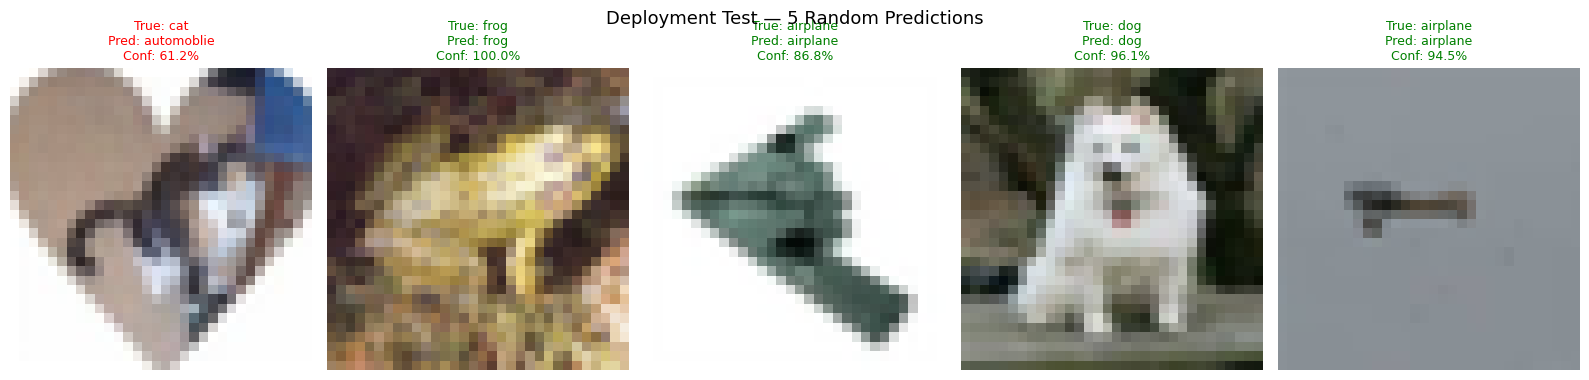

In [ ]:
# ── 5.3 Prediction Function ──────────────────────────────────────────────────
def predict_image(model, image, class_names):
    img_norm  = image.astype("float32") / 255.0
    img_batch = np.expand_dims(img_norm, axis=0)
    probs      = model.predict(img_batch, verbose=0)[0]
    pred_class = np.argmax(probs)
    confidence = probs[pred_class] * 100
    return class_names[pred_class], confidence, probs

# Test with 5 random images from the test set
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle("Deployment Test — 5 Random Predictions", fontsize=13)

random_idx = np.random.choice(len(x_test), 5, replace=False)
for i, idx in enumerate(random_idx):
    pred_name, confidence, probs = predict_image(loaded_model, x_test[idx], class_names)
    true_name = class_names[y_test[idx][0]]
    correct   = pred_name == true_name
    axes[i].imshow(x_test[idx])
    axes[i].set_title(
        f"True: {true_name}\nPred: {pred_name}\nConf: {confidence:.1f}%",
        color="green" if correct else "red", fontsize=9
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()
